In [1]:
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report,roc_curve,auc

In [ ]:
logestic_rg = joblib.load('models/log_reg.jbl')
random_forest = joblib.load('models/rf.jbl')
xgboost_clf = joblib.load('models/xgb_clf.jbl')

In [3]:
xtest = joblib.load('models/xtest.jbl')
ytest = joblib.load('models/ytest.jbl')

In [5]:
models = {
    'logestic_regression':logestic_rg,
    'randomforest_classifier':random_forest,
    'xgboost_classifier':xgboost_clf
}

In [8]:
for name,model in models.items():
    y_pred = model.predict(xtest)
    print('\n',name)
    print(classification_report(ytest,y_pred))


 logestic_regression
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      1969
           1       0.16      0.87      0.27        31

    accuracy                           0.93      2000
   macro avg       0.58      0.90      0.62      2000
weighted avg       0.98      0.93      0.95      2000


 randomforest_classifier
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1969
           1       0.29      0.55      0.38        31

    accuracy                           0.97      2000
   macro avg       0.64      0.76      0.68      2000
weighted avg       0.98      0.97      0.98      2000


 xgboost_classifier
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1969
           1       0.37      0.61      0.46        31

    accuracy                           0.98      2000
   macro avg       0.68      0.80      0.72      2000
weigh

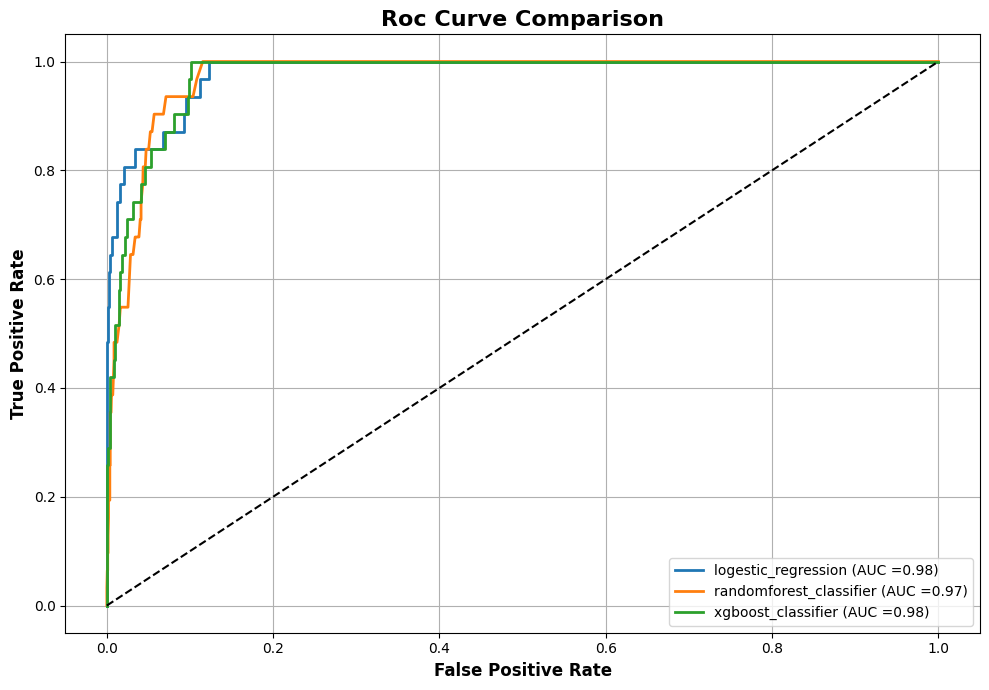

In [10]:
plt.figure(figsize=(10,7))
for name,model in models.items():
    y_proba = model.predict_proba(xtest)[:,1]
    fpr , tpr, _ = roc_curve(ytest,y_proba)
    roc_auc = auc(fpr,tpr)
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{name} (AUC ={roc_auc:.2f})'
    )
plt.plot([0,1],[0,1],'k--')
plt.title('Roc Curve Comparison',fontsize=16,weight='bold')
plt.xlabel('False Positive Rate',fontsize=12,weight='bold')
plt.ylabel('True Positive Rate',fontsize=12,weight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()